In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

### Load TLGRF Benchmark Dataset

In [2]:
benchmark_TLGRF_dataset = dd.read_csv("../benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])

df = benchmark_TLGRF_dataset.copy()
window_sizes = range(2,15)
fips_list = df["fips"].unique()

### Load Benchmark Data of $wsize \in \{2,3,4,\dotsc,13,14\}$

In [3]:
directory = "Fixed_Window_dfs"
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
def read_csv(file_path):
    return pd.read_csv(file_path)
with tqdm(total=len(file_paths), desc="Processing") as pbar:
    beta_results = Parallel(n_jobs=-1)(delayed(read_csv)(file_path) for file_path in file_paths)

### Check for Duplicates

In [5]:
present_fips_wsize_dict = {}
for fname in file_paths:
    fips = int(float(fname.split("=")[1].split("_")[0]))
    window_size = int(float(fname.split("=")[2].split(".")[0]))
    if fips not in present_fips_wsize_dict.keys():
        present_fips_wsize_dict[fips] = Counter()
    if window_size in present_fips_wsize_dict[fips].keys():
        print("Duplicate detected fips={} window_size={}".format(fips, window_size))
        present_fips_wsize_dict[fips][window_size] += 1
    else:
        present_fips_wsize_dict[fips].update({window_size : 1})

### Remove fips with too few entries

In [6]:
sorted_beta_results = sorted(beta_results, key = lambda x: (x["fips"].unique()[0], x.columns[2] ))

beta_result_dict_wsize_fips = {}
for beta_df in tqdm(sorted_beta_results):
    fips = int(beta_df["fips"].unique()[0])
    window_size = int(beta_df.columns[2].split("=")[1])
    if fips not in beta_result_dict_wsize_fips.keys():
        beta_result_dict_wsize_fips[fips] = {window_size:beta_df}
    else:
        beta_result_dict_wsize_fips[fips][window_size] = beta_df
        

counter = 0
problematic_fips = {}
for fips in tqdm(beta_result_dict_wsize_fips.keys()):
    counter += 1
    expected_shape = list(beta_result_dict_wsize_fips[fips].items())[0][1].shape
    #print("fips={} has expected shape {}".format(fips, expected_shape))
    have_windows = set(beta_result_dict_wsize_fips[fips].keys())
    missing_window_sizes = set(window_sizes) - set(have_windows)
    if len(missing_window_sizes):
        print("fips={} has missing window_sizes of {}".format(fips, missing_window_sizes))
        problematic_fips[fips] = missing_window_sizes
    for window_size in beta_result_dict_wsize_fips[fips].keys():
        current_shape = beta_result_dict_wsize_fips[fips][window_size].shape
        if current_shape != expected_shape:
            print("fips={}, wsize={} has shape {}, differing from expected {}".format(fips, window_size, expected_shape, current_shape))
        
print(len(fips_list) - counter)

fips=8057 has missing window_sizes of {13, 14}
fips=16025 has missing window_sizes of {10, 11, 12, 13, 14}
fips=31075 has missing window_sizes of {6, 7, 8, 9, 10, 11, 12, 13, 14}
fips=31085 has missing window_sizes of {5, 6, 7, 8, 9, 10, 11, 12, 13, 14}
fips=31091 has missing window_sizes of {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}
fips=31103 has missing window_sizes of {12, 13, 14}
fips=31115 has missing window_sizes of {5, 6, 7, 8, 9, 10, 11, 12, 13, 14}
fips=31183 has missing window_sizes of {11, 12, 13, 14}
fips=35021 has missing window_sizes of {10, 11, 12, 13, 14}
fips=38007 has missing window_sizes of {9, 10, 11, 12, 13, 14}
fips=48999 has missing window_sizes of {12, 13, 14}

0


In [7]:
beta_result_dict_wsize_fips[1001]

{10:      fips  days_from_start  beta_wsize=10
 0    1001               87            NaN
 1    1001               88            NaN
 2    1001               89            NaN
 3    1001               90            NaN
 4    1001               91            NaN
 ..    ...              ...            ...
 977  1001             1064       0.053762
 978  1001             1065       0.053535
 979  1001             1066       0.051529
 980  1001             1067       0.047831
 981  1001             1068       0.043796
 
 [982 rows x 3 columns],
 11:      fips  days_from_start  beta_wsize=11
 0    1001               87            NaN
 1    1001               88            NaN
 2    1001               89            NaN
 3    1001               90            NaN
 4    1001               91            NaN
 ..    ...              ...            ...
 977  1001             1064       0.053464
 978  1001             1065       0.053399
 979  1001             1066       0.052009
 980  1001         

### Merge Results

In [8]:
beta_result_dict = {window_size:[] for window_size in window_sizes}
for beta_df in tqdm(sorted_beta_results):
    fips = int(beta_df["fips"].unique()[0])
    window_size = int(beta_df.columns[2].split("=")[1])
    if fips not in problematic_fips.keys():
        beta_result_dict[window_size].append(beta_df)

concatenated_beta_result_dict = {}
for window_size, beta_df_list in tqdm(beta_result_dict.items()):
    concatenated_beta_result_dict[window_size] = pd.concat(beta_df_list)
#updated_df.to_csv("TLGRF_w_Fixed_Windows.csv", index=False)

In [9]:
concatenated_beta_result_dict

{2:        fips  days_from_start  beta_wsize=2
 0      1001               87           NaN
 1      1001               88      0.000000
 2      1001               89      0.013699
 3      1001               90      0.020203
 4      1001               91      0.000000
 ...     ...              ...           ...
 1013  99999             1064      0.020137
 1014  99999             1065      0.015797
 1015  99999             1066      0.012312
 1016  99999             1067      0.002081
 1017  99999             1068     -0.006364
 
 [2414825 rows x 3 columns],
 3:        fips  days_from_start  beta_wsize=3
 0      1001               87           NaN
 1      1001               88           NaN
 2      1001               89      0.006849
 3      1001               90      0.016951
 4      1001               91      0.010101
 ...     ...              ...           ...
 1013  99999             1064      0.024722
 1014  99999             1065      0.017967
 1015  99999             1066      0.01

In [10]:
beta_df_big = pd.DataFrame()
#for window_size, fips_beta_df in tqdm(concatenated_beta_result_dict.items()):
#    if not beta_df_big.shape[0]:
#        beta_df_big = fips_beta_df.copy()
#        continue
#    beta_df_big = pd.merge(beta_df_big, fips_beta_df, on="fips", how="outer")

beta_df_big = reduce(lambda left, right: pd.merge(left, right, on=['fips','days_from_start'], how='outer'), concatenated_beta_result_dict.values())


updated_df = pd.merge(df, beta_df_big,on=['fips','days_from_start'], how="outer").sort_values(by=["fips", 'days_from_start'])


In [11]:
updated_df

,fips,county,state,date,days_from_start,tau.hat,log_rolled_cases,shifted_log_rolled_cases,predicted.grf.future.last,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
0,1001.0,Autauga,Alabama,2020-04-17,87.0,0.026873,3.030824,3.122994,3.218935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001.0,Autauga,Alabama,2020-04-18,88.0,0.010264,3.030824,3.160035,3.102674,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001.0,Autauga,Alabama,2020-04-19,89.0,0.018760,3.044522,3.183989,3.175840,0.013699,0.006849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001.0,Autauga,Alabama,2020-04-20,90.0,0.021026,3.064725,3.213145,3.211908,0.020203,0.016951,0.011540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001.0,Autauga,Alabama,2020-04-21,91.0,0.012541,3.064725,3.241476,3.152509,0.000000,0.010101,0.012191,0.010170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2414905,99999.0,New York City,New York,2022-12-20,1064.0,0.019618,11.325935,11.308842,11.463264,0.020137,0.024722,0.026704,0.027903,0.027905,0.026864,0.025705,0.024682,0.023453,0.022157,0.020935,0.020056,0.019458
2414906,99999.0,New York City,New York,2022-12-21,1065.0,0.017220,11.341732,11.300346,11.462273,0.015797,0.017967,0.021586,0.023953,0.025595,0.026173,0.025749,0.025044,0.024328,0.023362,0.022280,0.021215,0.020416
2414907,99999.0,New York City,New York,2022-12-22,1066.0,0.014948,11.354044,11.290173,11.458682,0.012312,0.014054,0.016054,0.019104,0.021504,0.023348,0.024297,0.024332,0.024014,0.023589,0.022885,0.022026,0.021136
2414908,99999.0,New York City,New York,2022-12-23,1067.0,0.009073,11.356125,11.281184,11.419639,0.002081,0.007196,0.010288,0.012876,0.015963,0.018548,0.020639,0.021940,0.022398,0.022455,0.022335,0.021911,0.021296


In [12]:
filtered_updated_df = updated_df.dropna(subset=["beta_wsize=14"])
display(filtered_updated_df)

,fips,county,state,date,days_from_start,tau.hat,log_rolled_cases,shifted_log_rolled_cases,predicted.grf.future.last,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
13,1001.0,Autauga,Alabama,2020-04-30,100.0,0.032027,3.311585,3.452253,3.535773,0.037140,0.035055,0.032829,0.031649,0.030213,0.030431,0.031192,0.030345,0.028621,0.026379,0.024849,0.023556,0.022070
14,1001.0,Autauga,Alabama,2020-05-01,101.0,-0.011272,3.306363,3.526361,3.227463,-0.005222,0.015959,0.023180,0.025655,0.026862,0.026981,0.027869,0.028990,0.028697,0.027535,0.025806,0.024576,0.023492
15,1001.0,Autauga,Alabama,2020-05-02,102.0,0.019009,3.321948,3.583519,3.455013,0.015585,0.005181,0.013729,0.019286,0.022166,0.023944,0.024685,0.025855,0.027138,0.027203,0.026449,0.025122,0.024147
16,1001.0,Autauga,Alabama,2020-05-03,103.0,0.021458,3.342357,3.659892,3.492561,0.020409,0.017997,0.010790,0.014619,0.018334,0.020732,0.022433,0.023329,0.024532,0.025822,0.026079,0.025594,0.024558
17,1001.0,Autauga,Alabama,2020-05-04,104.0,0.033519,3.377100,3.741065,3.611732,0.034743,0.027576,0.023262,0.016702,0.017748,0.019752,0.021302,0.022549,0.023260,0.024275,0.025406,0.025686,0.025318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2414905,99999.0,New York City,New York,2022-12-20,1064.0,0.019618,11.325935,11.308842,11.463264,0.020137,0.024722,0.026704,0.027903,0.027905,0.026864,0.025705,0.024682,0.023453,0.022157,0.020935,0.020056,0.019458
2414906,99999.0,New York City,New York,2022-12-21,1065.0,0.017220,11.341732,11.300346,11.462273,0.015797,0.017967,0.021586,0.023953,0.025595,0.026173,0.025749,0.025044,0.024328,0.023362,0.022280,0.021215,0.020416
2414907,99999.0,New York City,New York,2022-12-22,1066.0,0.014948,11.354044,11.290173,11.458682,0.012312,0.014054,0.016054,0.019104,0.021504,0.023348,0.024297,0.024332,0.024014,0.023589,0.022885,0.022026,0.021136
2414908,99999.0,New York City,New York,2022-12-23,1067.0,0.009073,11.356125,11.281184,11.419639,0.002081,0.007196,0.010288,0.012876,0.015963,0.018548,0.020639,0.021940,0.022398,0.022455,0.022335,0.021911,0.021296


In [13]:
predictor_columns = ["tau.hat"] + ["beta_wsize={}".format(window_size) for window_size in range(2,15)]

In [14]:
MAE_df = pd.DataFrame()
RMSE_df = pd.DataFrame()
for predictor_column in tqdm(predictor_columns):
    predictor_MAE = filtered_updated_df.groupby("days_from_start").apply(lambda x: mean_absolute_error(x[predictor_column]*7+x["log_rolled_cases"], x["shifted_log_rolled_cases"]))
    predictor_RMSE = filtered_updated_df.groupby("days_from_start").apply(lambda x: mean_squared_error(x[predictor_column]*7+x["log_rolled_cases"], x["shifted_log_rolled_cases"], squared=False))
    MAE_df[predictor_column] = predictor_MAE
    RMSE_df[predictor_column] = predictor_RMSE

In [15]:
MAE_df

,tau.hat,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
days_from_start,,,,,,,,,,,,,,
64.0,0.585082,0.400423,0.433282,0.489737,0.535223,0.576090,0.617946,0.654585,0.680395,0.687667,0.683266,0.676504,0.676806,0.684497
65.0,0.570530,0.381678,0.413557,0.432620,0.455395,0.501841,0.546841,0.591105,0.630743,0.661797,0.678897,0.682891,0.680960,0.680588
66.0,0.566608,0.382032,0.434144,0.463434,0.493718,0.533086,0.576880,0.621852,0.678959,0.725769,0.757104,0.773945,0.777596,0.776383
67.0,0.559118,0.335433,0.397392,0.452134,0.484682,0.518870,0.559506,0.606754,0.651994,0.694318,0.727554,0.752184,0.768729,0.772838
68.0,0.502848,0.342665,0.414493,0.478955,0.529935,0.567979,0.597492,0.624187,0.655232,0.686114,0.715221,0.735980,0.746017,0.746126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064.0,0.166655,0.174259,0.180594,0.189436,0.197148,0.200758,0.199116,0.196549,0.193415,0.190144,0.187223,0.184987,0.184339,0.184957
1065.0,0.146908,0.160649,0.155464,0.164251,0.176960,0.188409,0.195254,0.196831,0.196589,0.195057,0.193037,0.191109,0.189271,0.188493
1066.0,0.146450,0.154612,0.162707,0.161246,0.165491,0.173999,0.183665,0.191010,0.193906,0.195404,0.195486,0.194845,0.194053,0.192971


In [16]:
RMSE_df

,tau.hat,beta_wsize=2,beta_wsize=3,beta_wsize=4,beta_wsize=5,beta_wsize=6,beta_wsize=7,beta_wsize=8,beta_wsize=9,beta_wsize=10,beta_wsize=11,beta_wsize=12,beta_wsize=13,beta_wsize=14
days_from_start,,,,,,,,,,,,,,
64.0,0.626877,0.544367,0.606291,0.690793,0.748845,0.799293,0.866672,0.923786,0.958294,0.957798,0.940372,0.920846,0.914577,0.917332
65.0,0.639908,0.468435,0.533852,0.589364,0.658863,0.716066,0.766825,0.827592,0.881451,0.918440,0.928368,0.921651,0.909859,0.905524
66.0,0.598247,0.421099,0.485767,0.540339,0.602281,0.679826,0.759082,0.834935,0.911759,0.970055,1.001053,1.007006,0.998025,0.986506
67.0,0.587307,0.378423,0.434442,0.493036,0.539391,0.593301,0.658977,0.730425,0.799039,0.867777,0.923280,0.957805,0.970582,0.968926
68.0,0.521226,0.374553,0.454299,0.518553,0.568319,0.610887,0.647069,0.687102,0.737945,0.793239,0.849897,0.894259,0.922049,0.934063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064.0,0.260425,0.270676,0.277562,0.287492,0.297333,0.299235,0.290198,0.281841,0.275016,0.269292,0.266028,0.263735,0.262263,0.262544
1065.0,0.224934,0.299956,0.236701,0.243031,0.258264,0.273244,0.280095,0.274854,0.268202,0.261747,0.255829,0.252241,0.249225,0.247512
1066.0,0.230064,0.256689,0.287209,0.258963,0.253808,0.259961,0.271266,0.277657,0.273427,0.267410,0.261308,0.255587,0.251949,0.248716


In [17]:
MAE_df.median()

tau.hat          0.131344
beta_wsize=2     0.142197
beta_wsize=3     0.148805
beta_wsize=4     0.154757
beta_wsize=5     0.161010
beta_wsize=6     0.165373
beta_wsize=7     0.169121
beta_wsize=8     0.173130
beta_wsize=9     0.176485
beta_wsize=10    0.179821
beta_wsize=11    0.183108
beta_wsize=12    0.186130
beta_wsize=13    0.188884
beta_wsize=14    0.191907
dtype: float64

In [18]:
RMSE_df.median()

tau.hat          0.208404
beta_wsize=2     0.238367
beta_wsize=3     0.240962
beta_wsize=4     0.245151
beta_wsize=5     0.250313
beta_wsize=6     0.254816
beta_wsize=7     0.258551
beta_wsize=8     0.261356
beta_wsize=9     0.263172
beta_wsize=10    0.263849
beta_wsize=11    0.263847
beta_wsize=12    0.263822
beta_wsize=13    0.264638
beta_wsize=14    0.266226
dtype: float64

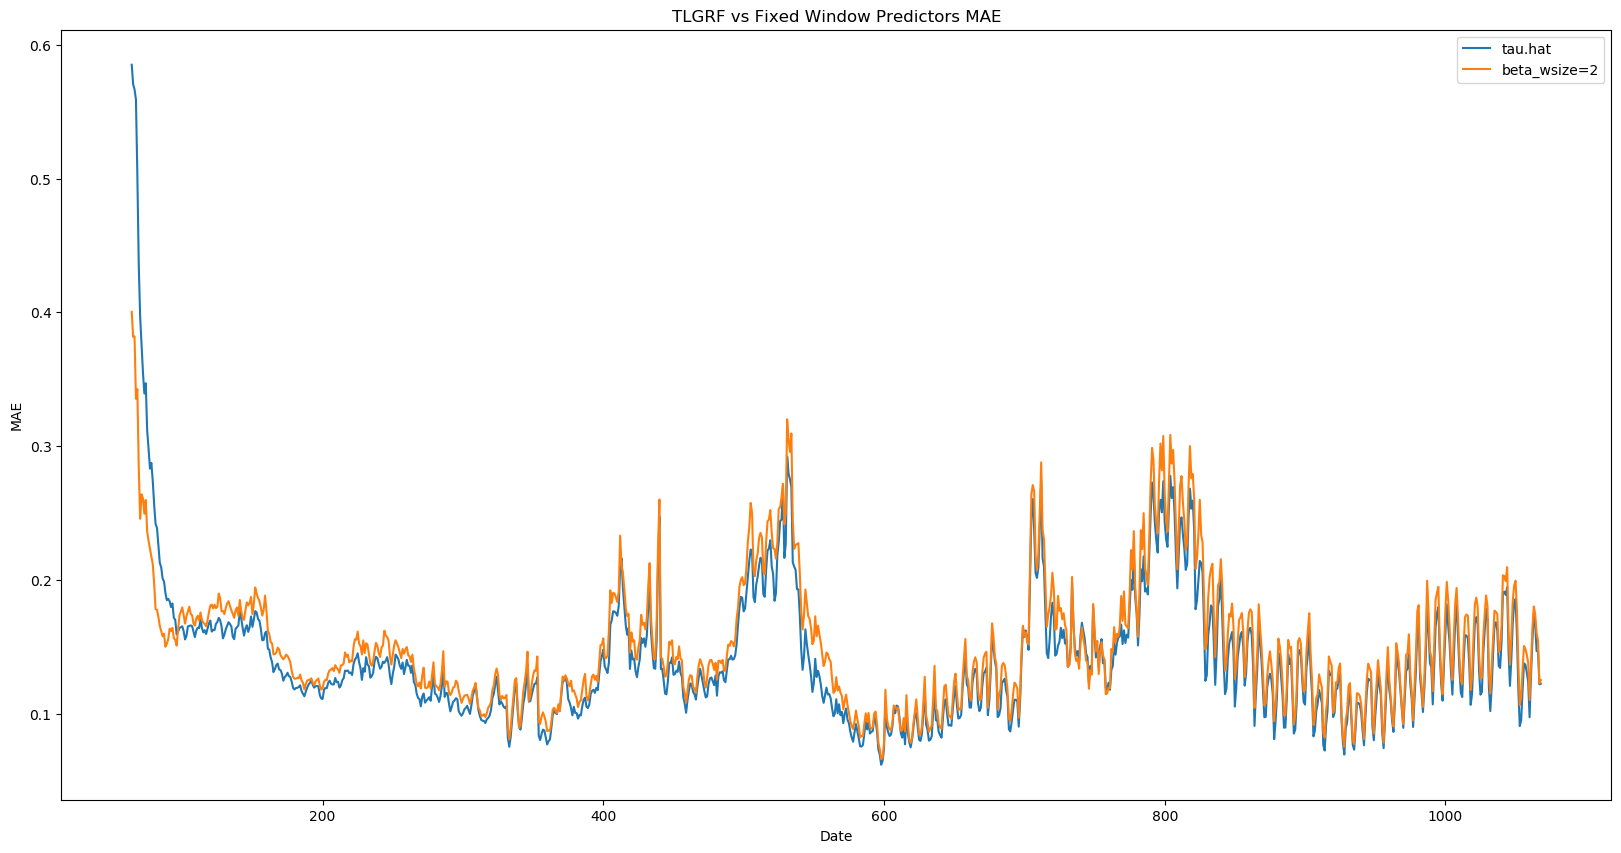

In [23]:
plt.figure(figsize=(20,10))
plot_columns =  ["tau.hat"] + ["beta_wsize={}".format(window_size) for window_size in [2,7,14]]
plot_columns =  ["tau.hat"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
for plot_column in tqdm(plot_columns):
    plt.plot(MAE_df[plot_column], label=plot_column)
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Fixed Window Predictors MAE")
plt.legend()
plt.show()

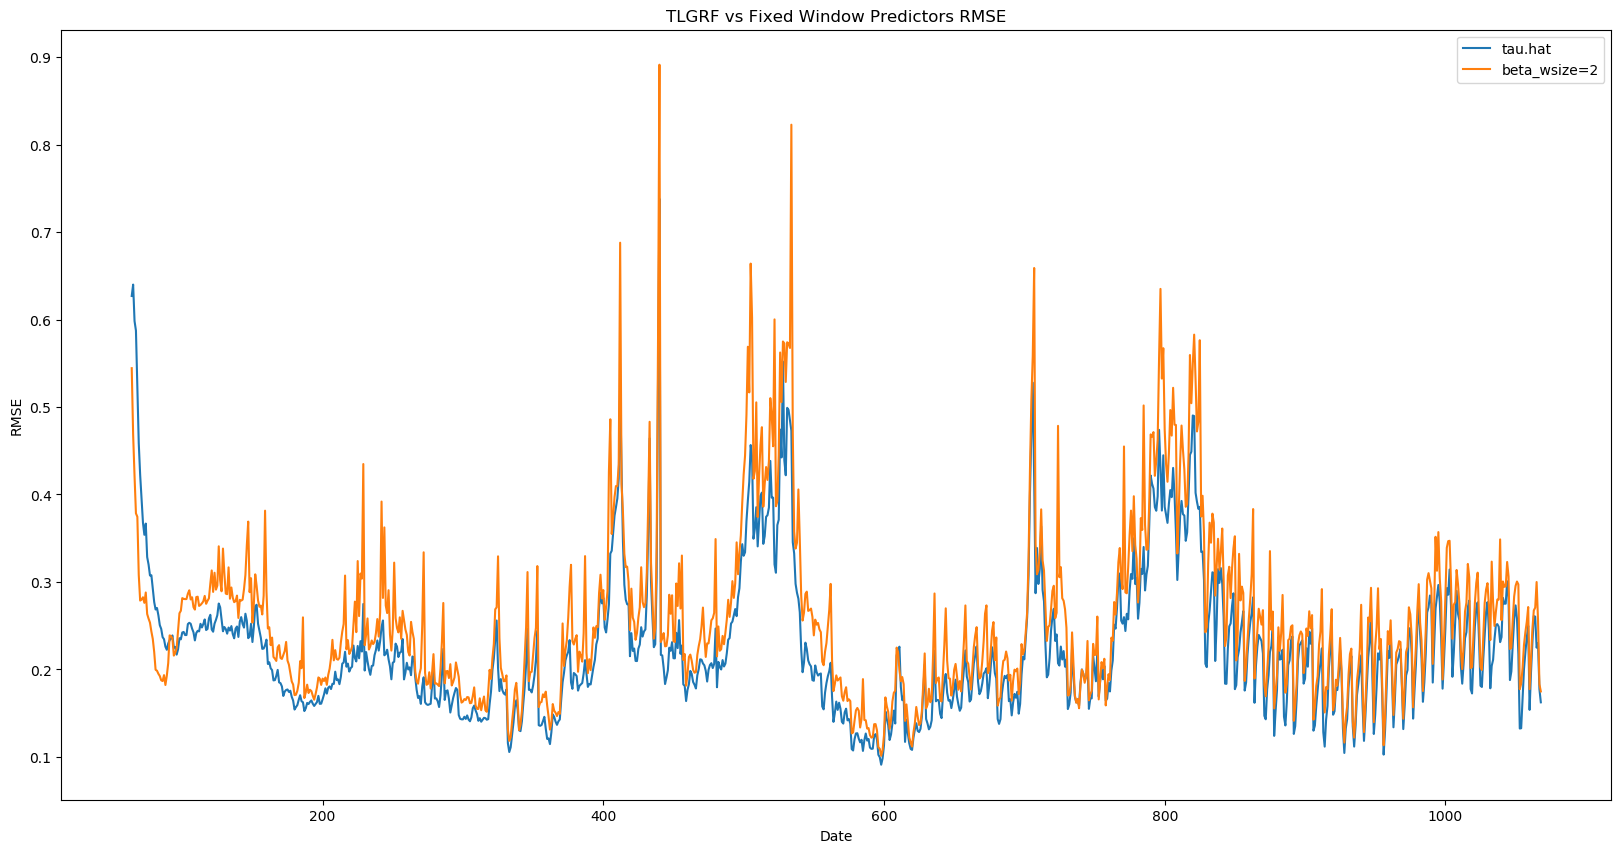

In [25]:
plt.figure(figsize=(20,10))
plot_columns =  ["tau.hat"] + ["beta_wsize={}".format(window_size) for window_size in [2,7,14]]
plot_columns =  ["tau.hat"] + ["beta_wsize={}".format(window_size) for window_size in [2]]
for plot_column in tqdm(plot_columns):
    plt.plot(RMSE_df[plot_column], label=plot_column)
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Fixed Window Predictors RMSE")
plt.legend()
plt.show()